In [1]:
import pandas as pd
sales = pd.read_csv('retail_store_sales.csv')

In [2]:
sales.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Total Sale,Total Spent,Payment Method,Location,Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,30-11-2023,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,10-06-2023,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,02-04-2024,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,26-04-2023,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,14-03-2024,False


In [3]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Total Sale        11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Date              12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [4]:
sales.describe()

,Price Per Unit,Total Sale,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [5]:
sales.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Total Sale           604
Total Spent          604
Payment Method         0
Location               0
Date                   0
Discount Applied    4199
dtype: int64

In [6]:
sales.shape

(12575, 11)

In [7]:
sales.duplicated().sum()

np.int64(0)

In [8]:
for col in sales.columns:
    if sales[col].nunique()<20:
        print(sales[col].value_counts())
        print('-'*50)

Category
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64
--------------------------------------------------
Total Sale
10.0    1232
5.0     1228
7.0     1227
8.0     1226
3.0     1224
6.0     1220
2.0     1164
4.0     1155
9.0     1148
1.0     1147
Name: count, dtype: int64
--------------------------------------------------
Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64
--------------------------------------------------
Location
Online      6354
In-store    6221
Name: count, dtype: int64
--------------------------------------------------
Discount Applied
True     4219
False    4157
Name: count, dtype: int64


In [9]:
sales.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Total Sale           604
Total Spent          604
Payment Method         0
Location               0
Date                   0
Discount Applied    4199
dtype: int64

In [10]:
sales['Category'].unique()

array(['Patisserie', 'Milk Products', 'Butchers', 'Beverages', 'Food',
       'Furniture', 'Electric household essentials',
       'Computers and electric accessories'], dtype=object)

In [11]:
sales['Item'].isna().sum()

np.int64(1213)

In [12]:

sales.columns = sales.columns.str.strip()

def fill_item_with_mode(x):
    mode_val = x['Item'].mode()
    if not mode_val.empty:
        return x['Item'].fillna(mode_val[0])
    else:
        return x['Item']  

sales['Item'] = sales.groupby('Category', group_keys=False).apply(fill_item_with_mode)


C:\Users\karan\AppData\Local\Temp\ipykernel_4048\1920075195.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sales['Item'] = sales.groupby('Category', group_keys=False).apply(fill_item_with_mode)


In [13]:
sales.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Total Sale,Total Spent,Payment Method,Location,Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
5,TXN_7482416,CUST_09,Patisserie,Item_12_PAT,NaN,10.0,200.0,Credit Card,Online,30-11-2023,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,10-06-2023,True
7,TXN_1372952,CUST_21,Furniture,Item_25_FUR,33.5,NaN,NaN,Digital Wallet,In-store,02-04-2024,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,26-04-2023,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,14-03-2024,False


In [14]:
mask = sales['Total Spent'].isna() & sales['Price Per Unit'].notna() & sales['Total Sale'].notna()
sales.loc[mask, 'Total Spent'] = sales.loc[mask, 'Price Per Unit'] * sales.loc[mask, 'Total Sale']

In [15]:
sales.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Total Sale,Total Spent,Payment Method,Location,Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,08-04-2024,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,23-07-2023,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,05-10-2022,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,07-05-2022,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,02-10-2022,False
5,TXN_7482416,CUST_09,Patisserie,Item_12_PAT,NaN,10.0,200.0,Credit Card,Online,30-11-2023,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,10-06-2023,True
7,TXN_1372952,CUST_21,Furniture,Item_25_FUR,33.5,NaN,NaN,Digital Wallet,In-store,02-04-2024,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,26-04-2023,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,14-03-2024,False


In [16]:
mask = sales['Price Per Unit'].isna() & sales['Total Spent'].notna() & sales['Total Sale'].notna()
sales.loc[mask, 'Price Per Unit'] = sales.loc[mask, 'Total Spent'] / sales.loc[mask, 'Total Sale']

In [17]:
mask = sales['Total Sale'].isna() & sales['Total Spent'].notna() & sales['Price Per Unit'].notna()
sales.loc[mask, 'Total Sale'] = sales.loc[mask, 'Total Spent'] / sales.loc[mask, 'Price Per Unit']

In [18]:
sales.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Total Sale           604
Total Spent          604
Payment Method         0
Location               0
Date                   0
Discount Applied    4199
dtype: int64

In [19]:
sales['Total Sale'] = (
    sales.groupby('Category')['Total Sale']
         .transform(lambda x: x.fillna(x.median()))
)

In [20]:
sales.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Total Sale             0
Total Spent          604
Payment Method         0
Location               0
Date                   0
Discount Applied    4199
dtype: int64

In [21]:
mask = sales['Total Spent'].isna()
sales.loc[mask, 'Total Spent'] = sales.loc[mask, 'Price Per Unit'] * sales.loc[mask, 'Total Sale']

In [22]:
check_diff = abs(sales['Total Spent'] - (sales['Price Per Unit'] * sales['Total Sale']))
print("Max difference:", check_diff.max())

Max difference: 0.0


In [23]:
sales['Discount Applied'] = sales['Discount Applied'].fillna(sales['Discount Applied'].mode()[0])

C:\Users\karan\AppData\Local\Temp\ipykernel_4048\3763320414.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sales['Discount Applied'] = sales['Discount Applied'].fillna(sales['Discount Applied'].mode()[0])


In [24]:
sales.isna().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Total Sale          0
Total Spent         0
Payment Method      0
Location            0
Date                0
Discount Applied    0
dtype: int64

In [25]:
sales.dtypes

Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Total Sale          float64
Total Spent         float64
Payment Method       object
Location             object
Date                 object
Discount Applied       bool
dtype: object

In [26]:
sales['Date'] = pd.to_datetime(sales['Date'], format='%d-%m-%Y')
sales = sales.set_index('Date')


In [27]:
sales.dtypes

Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Total Sale          float64
Total Spent         float64
Payment Method       object
Location             object
Discount Applied       bool
dtype: object

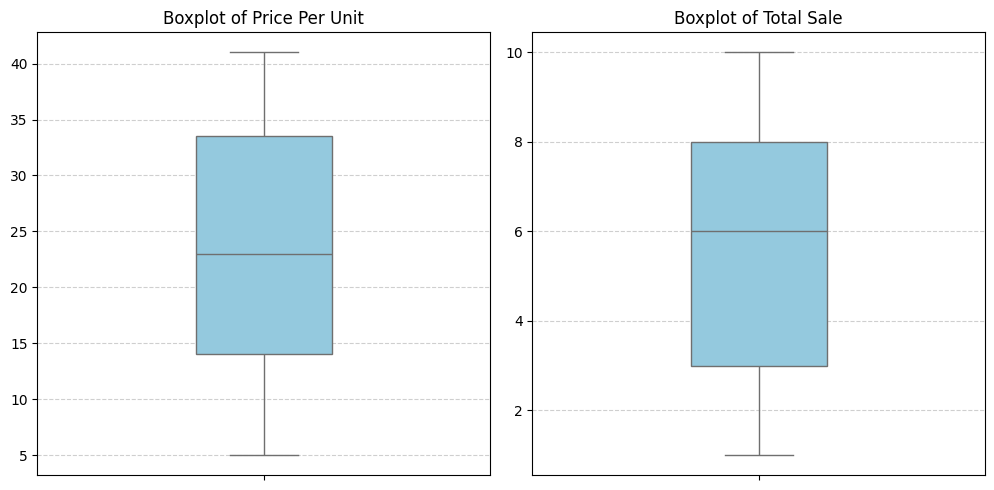

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Price Per Unit', 'Total Sale']

plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=sales[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

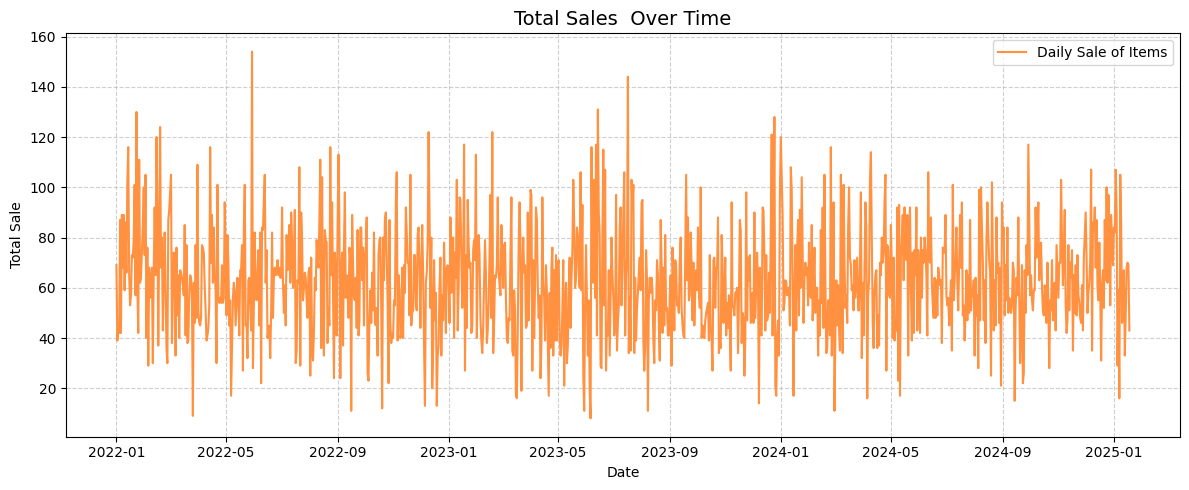

In [29]:
daily_sales = sales.groupby('Date')['Total Sale'].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales, color='#ff9140', label='Daily Sale of Items')
plt.title('Total Sales  Over Time', fontsize=14)
plt.ylabel('Total Sale')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [30]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test
adf_test = adfuller(sales['Total Sale'])

# Extract and display the results
print("Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print(f"Number of Lags Used: {adf_test[2]}")
print(f"Number of Observations Used: {adf_test[3]}")
print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"\t{key}: {value}")

Augmented Dickey-Fuller Test Results:
ADF Statistic: -112.54349856736823
p-value: 0.0
Number of Lags Used: 0
Number of Observations Used: 12574
Critical Values:
	1%: -3.43087017142352
	5%: -2.86176989000953
	10%: -2.566892365468227


In [31]:
from statsmodels.tsa.stattools import kpss

# Perform the KPSS test
kpss_test = kpss(sales['Total Sale'], regression='ct', nlags='auto')

# Extract and display the results
print("KPSS Test Results:")
print(f"KPSS Statistic: {kpss_test[0]}")
print(f"p-value: {kpss_test[1]}")
print(f"Lags Used: {kpss_test[2]}")
print("Critical Values:")
for key, value in kpss_test[3].items():
    print(f"\t{key}: {value}")

KPSS Test Results:
KPSS Statistic: 0.029251224814785943
p-value: 0.1
Lags Used: 2
Critical Values:
	10%: 0.119
	5%: 0.146
	2.5%: 0.176
	1%: 0.216


C:\Users\karan\AppData\Local\Temp\ipykernel_4048\1620985462.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(sales['Total Sale'], regression='ct', nlags='auto')


C:\Users\karan\AppData\Local\Temp\ipykernel_4048\776888055.py:14: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  trend_smooth = trend_additive.resample('w').mean()
C:\Users\karan\AppData\Local\Temp\ipykernel_4048\776888055.py:15: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  seasonal_smooth = seasonal_additive.resample('w').mean()
C:\Users\karan\AppData\Local\Temp\ipykernel_4048\776888055.py:16: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  residual_smooth = residual_additive.resample('w').mean()


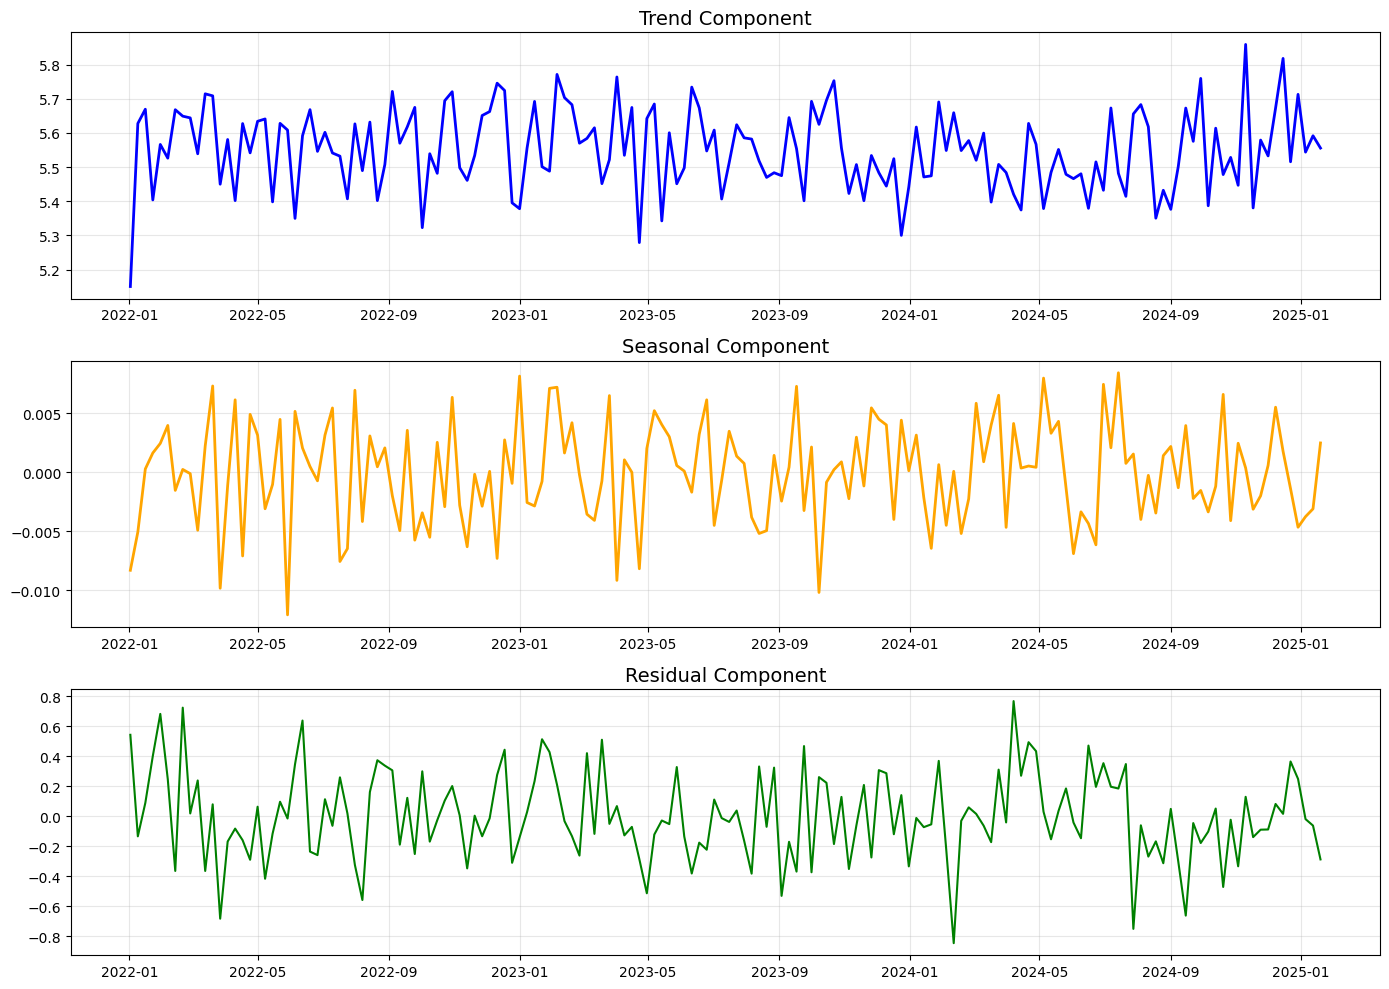

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

#sales['Date'] = pd.to_datetime(sales['Date'])
#sales = sales.set_index('Date')

decomposition_additive = seasonal_decompose(sales['Total Sale'], model='additive', period=7)

trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

# Downsample to weekly averages (you can adjust to 'M' for monthly)
trend_smooth = trend_additive.resample('w').mean()
seasonal_smooth = seasonal_additive.resample('w').mean()
residual_smooth = residual_additive.resample('w').mean()

# Plot cleanly
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(trend_smooth, color='blue', linewidth=2)
plt.title('Trend Component', fontsize=14)
plt.grid(alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(seasonal_smooth, color='orange', linewidth=2)
plt.title('Seasonal Component', fontsize=14)
plt.grid(alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(residual_smooth, color='green', linewidth=1.5)
plt.title('Residual Component', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


KS Statistic: 0.014746542706364075
p-value: 0.4931470001554326
✅ Series is likely strictly stationary (distributions are similar)


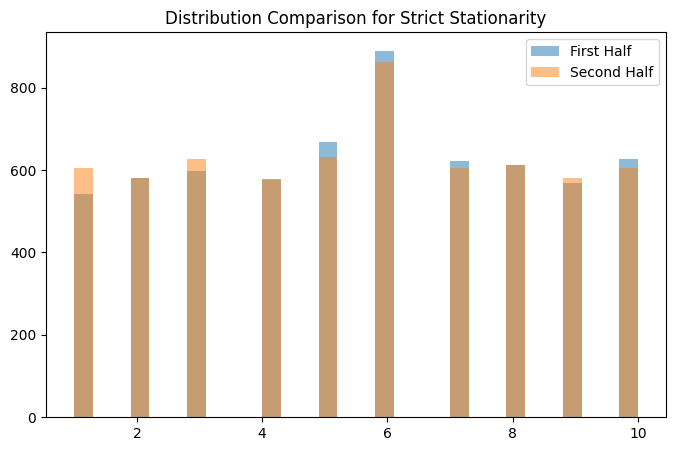

In [33]:
import pandas as pd
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

sales = sales.sort_values('Date')

# --- Step 3: Select your numeric column ---
data = sales['Total Sale'].dropna().values  # change 'Quantity' if needed

# --- Step 4: Split into halves (you can also use 3 or 4 chunks) ---
n = len(data)
half = n // 2
first_half = data[:half]
second_half = data[half:]

# --- Step 5: KS Test ---
ks_stat, p_value = ks_2samp(first_half, second_half)

print("KS Statistic:", ks_stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("✅ Series is likely strictly stationary (distributions are similar)")
else:
    print("❌ Series is not strictly stationary (distributions differ)")

# --- Step 6 (Optional): Plot distributions ---
plt.figure(figsize=(8,5))
plt.hist(first_half, bins=30, alpha=0.5, label='First Half')
plt.hist(second_half, bins=30, alpha=0.5, label='Second Half')
plt.title("Distribution Comparison for Strict Stationarity")
plt.legend()
plt.show()

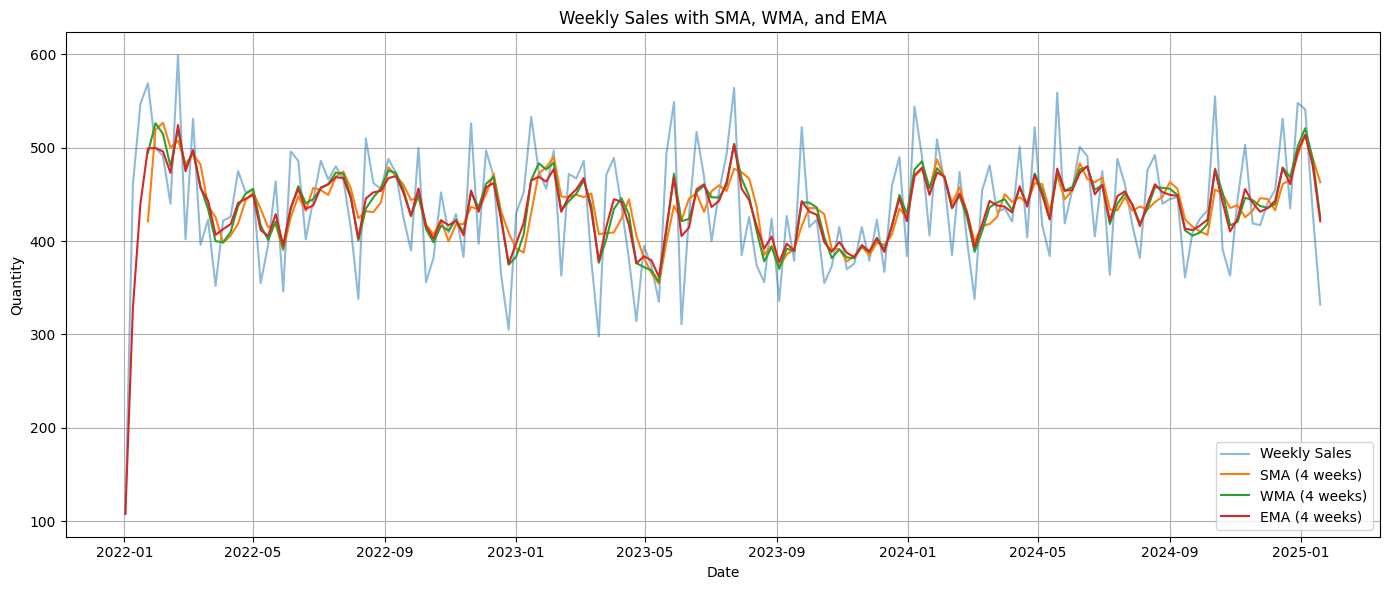

In [34]:
import numpy as np
import matplotlib.pyplot as plt


# ✅ Resample to weekly sales
weekly_sales = sales['Total Sale'].resample('W').sum()

window_size = 4  # 4 weeks (~1 month)

# Moving Averages
SMA = weekly_sales.rolling(window=window_size).mean()
weights = np.arange(1, window_size + 1)
WMA = weekly_sales.rolling(window_size).apply(
    lambda prices: np.dot(prices, weights) / weights.sum(), raw=True
)
EMA = weekly_sales.ewm(span=window_size).mean()

# ✅ Plotting
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales, label='Weekly Sales', alpha=0.5)
plt.plot(SMA, label=f'SMA ({window_size} weeks)')
plt.plot(WMA, label=f'WMA ({window_size} weeks)')
plt.plot(EMA, label=f'EMA ({window_size} weeks)')

plt.title('Weekly Sales with SMA, WMA, and EMA')
plt.xlabel('Date')
plt.ylabel('Quantity')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

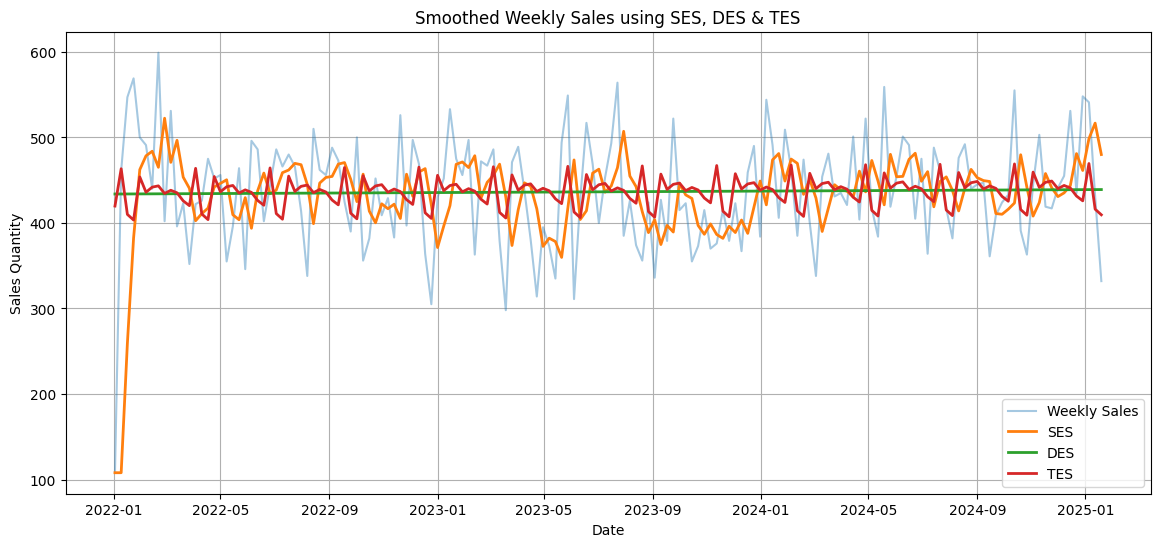

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing


# ✅ Convert daily → weekly aggregated quantity
weekly_sales = sales['Total Sale'].resample('W').sum()

# ✅ Fit models on weekly data
ses_model = SimpleExpSmoothing(weekly_sales).fit()
weekly_sales_ses = ses_model.fittedvalues

des_model = ExponentialSmoothing(weekly_sales, trend='add').fit()
weekly_sales_des = des_model.fittedvalues

tes_model = ExponentialSmoothing(weekly_sales, trend='add', seasonal='add', seasonal_periods=12).fit()
weekly_sales_tes = tes_model.fittedvalues

# ✅ Plot smooth weekly signals
plt.figure(figsize=(14,6))
plt.plot(weekly_sales, label="Weekly Sales", alpha=0.4)
plt.plot(weekly_sales_ses, label="SES", linewidth=2)
plt.plot(weekly_sales_des, label="DES", linewidth=2)
plt.plot(weekly_sales_tes, label="TES", linewidth=2)

plt.title("Smoothed Weekly Sales using SES, DES & TES")
plt.xlabel("Date")
plt.ylabel("Sales Quantity")
plt.legend()
plt.grid()
plt.show()

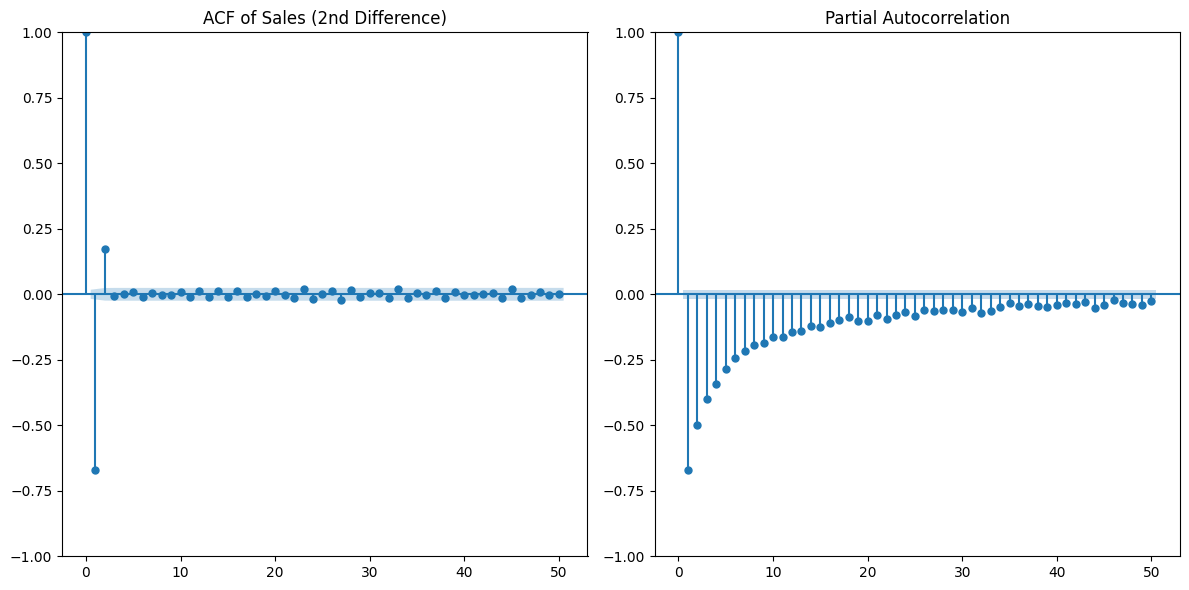

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# ✅ ACF Plot
plt.subplot(1,2,1)
plot_acf(sales['Total Sale'].diff().diff().dropna(), ax=plt.gca(), lags=50)
plt.title('ACF of Sales (2nd Difference)')

# ✅ PACF Plot
plt.subplot(1,2,2)
plot_pacf(sales['Total Sale'].diff().diff().dropna(), ax=plt.gca(), lags=50, method='ywm')

plt.tight_layout()
plt.show()

c:\Users\karan\OneDrive\Desktop\Sales_Data_Analysis\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\karan\OneDrive\Desktop\Sales_Data_Analysis\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\karan\OneDrive\Desktop\Sales_Data_Analysis\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


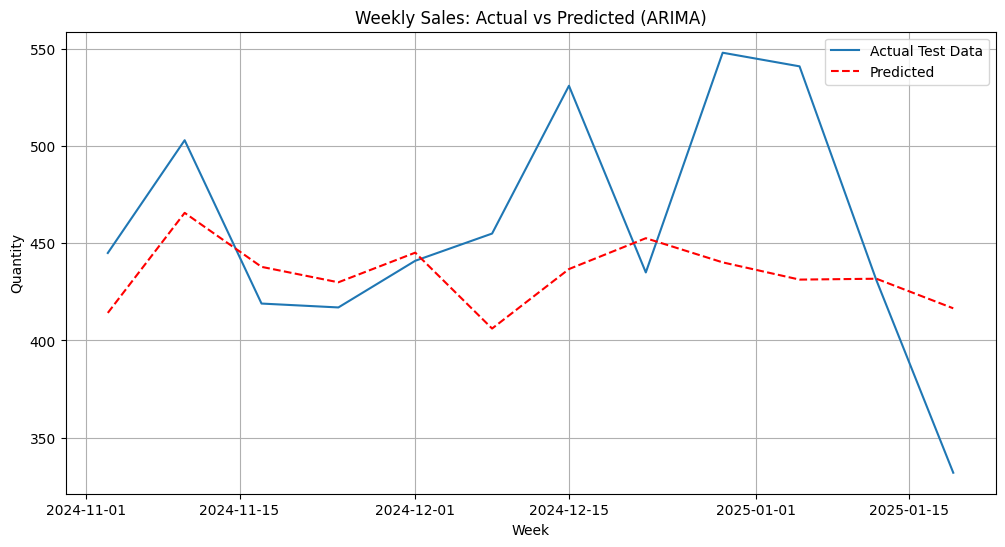

RMSE: 61.42


In [37]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# ✅ Convert Daily → Weekly aggregated sales
weekly_sales = sales['Total Sale'].resample('W').sum()

h = 12  # forecast horizon = 12 weeks
train_data = weekly_sales.iloc[:-h]
test_data = weekly_sales.iloc[-h:]



# ✅ Fit ARIMA model
model = ARIMA(train_data, order=(7,1,7))
model_fit = model.fit()

# ✅ Make predictions on test period
predictions = model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data) - 1,
    dynamic=False
)

# ✅ Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted')

plt.title('Weekly Sales: Actual vs Predicted (ARIMA)')
plt.xlabel('Week')
plt.ylabel('Quantity')
plt.legend()
plt.grid()
plt.show()

# ✅ RMSE
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print("RMSE:", rmse)

In [38]:
model = ARIMA(train_data, order=(1,2,1))
model_fit = model.fit()
predictions = model_fit.predict(start=len(train_data), end=len(train_data)+len(test_data)-1)
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print("RMSE ARIMA(1,2,1):", rmse)

RMSE ARIMA(1,2,1): 99.57


c:\Users\karan\OneDrive\Desktop\Sales_Data_Analysis\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


RMSE SARIMA: 105.4


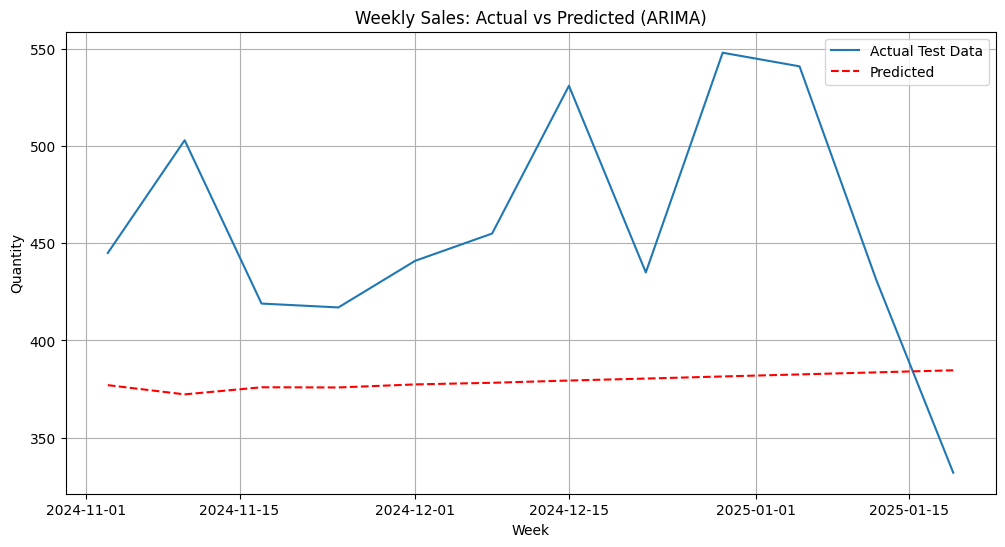

RMSE: 99.57


In [39]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(train_data, order=(1,1,1), seasonal_order=(1,1,1,52),
                       enforce_stationarity=False, enforce_invertibility=False).fit()
pred_sarima = model_sarima.forecast(len(test_data))
rmse_sarima = round(np.sqrt(mean_squared_error(test_data, pred_sarima)), 2)
print("RMSE SARIMA:", rmse_sarima)

# ✅ Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted')

plt.title('Weekly Sales: Actual vs Predicted (ARIMA)')
plt.xlabel('Week')
plt.ylabel('Quantity')
plt.legend()
plt.grid()
plt.show()

# ✅ RMSE
rmse = round(np.sqrt(mean_squared_error(test_data, predictions)), 2)
print("RMSE:", rmse)